In [1]:
import yaml
import matplotlib.pyplot as plt

from shapely.geometry import Polygon
import sys
from pathlib import Path
from shapely.ops import unary_union
import shapely
import numpy as np
from shapely.geometry.multipolygon import MultiPolygon
ROOT = Path.cwd()

# se il notebook viene eseguito dalla cartella notebooks/
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

BENCHMARK_ROOT = ROOT / "external" / "thomas-wflo-benchmark"

BOUNDARY_FILE = (
    BENCHMARK_ROOT
    / "src"
    / "input-files"
    / "farms"
    / "iea37-boundary-cs4.yaml"
)

In [2]:
def get_farm_area(BOUNDARY_FILE):
    
    with open(BOUNDARY_FILE) as f:
        boundary_data = yaml.safe_load(f)

    region_names = boundary_data['boundaries'].keys()

    polygons = []

    for region_name in region_names:
        region_coords = boundary_data['boundaries'][region_name]
        polygon = Polygon(region_coords)
        polygons.append(polygon)

    # Defining the union of the 5 regions
    farm_area = unary_union(polygons) 
    return polygons, farm_area

polygons, farm_area = get_farm_area(BOUNDARY_FILE)


In [5]:
# Creating the mask

def get_mask(farm_area: MultiPolygon, GRID_STEP: int=200):
    """
    GRID_STEP (int): grid step in meters
    """

    # Define the rectangular area including all the polygons
    min_x, min_y, max_x, max_y = farm_area.bounds
    x_coords = np.arange(min_x, max_x + GRID_STEP, GRID_STEP)
    y_coords = np.arange(min_y, max_y + GRID_STEP, GRID_STEP)
    X, Y = np.meshgrid(x_coords, y_coords)

    # Building the mask (i.e. force all the point outside the polygons to have value 0)
    points = shapely.points(X.ravel(), Y.ravel())
    inside = shapely.covers(farm_area, points)
    mask = inside.reshape(X.shape)

    return X, Y, mask

X, Y, mask = get_mask(farm_area=farm_area, GRID_STEP=75)

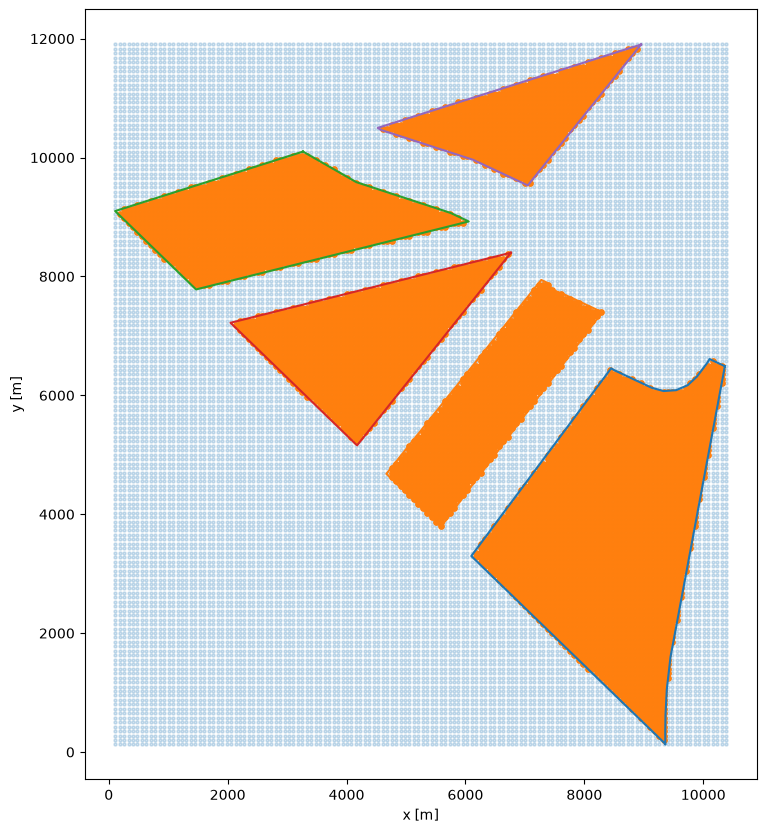

In [6]:
# Visualize the final grid
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# Tutta la griglia
ax.scatter(
    X.ravel(),
    Y.ravel(),
    s=5,
    alpha=0.2,
)

# Solo punti validi
ax.scatter(
    X[mask],
    Y[mask],
    s=15,
)

# Boundary
for polygon in polygons:
    bx, by = polygon.exterior.xy
    ax.plot(bx, by)

ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")

plt.show()